# Stock Price Prediction

Predicting the closing price of a stock using an LSTM neural network. The example uses **MSFT** (Microsoft), but you can swap the ticker, re-run the notebook, and get predictions for any company.

## 1. Setup

Import libraries, confirm PyTorch version, and check GPU availability.

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.12.1+cu130
CUDA build: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cuda')

## 2. Data Collection

Download historical daily price data using `yfinance`. Set `ticker` and `start_date` to pull data for any company.

In [4]:
ticker = 'MSFT'
start_date = '2025-01-01'

df = yf.download(ticker, start=start_date)

[*********************100%***********************]  1 of 1 completed


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2025-01-02,413.672638,421.074847,409.986387,420.541170,16896500
2025-01-03,418.386719,419.058739,414.621389,416.143313,16662900
2025-01-06,422.833984,429.228133,420.491775,422.982220,20573600
2025-01-07,417.418152,425.601076,415.866551,423.970427,18139100
2025-01-08,419.582550,421.964299,416.597967,418.495440,15054600


Each row is one trading day. The columns give us the standard OHLCV breakdown — **Open** and **Close** are the prices at market open and close, **High** and **Low** are the intraday extremes, and **Volume** is the number of shares traded. We'll focus on **Close** as the prediction target, since it's the most widely used reference price.

## 3. Visualisation

Each subplot covers one calendar quarter. MSFT opened 2025 around **$413–$422** and trended upward through Q1–Q2 2025 before pulling back. By mid-2026 the price sits in the **$380–$400** range, suggesting a gradual decline from the earlier highs. Splitting by quarter makes it easier to see whether the model struggles with a particular period or direction of trend.

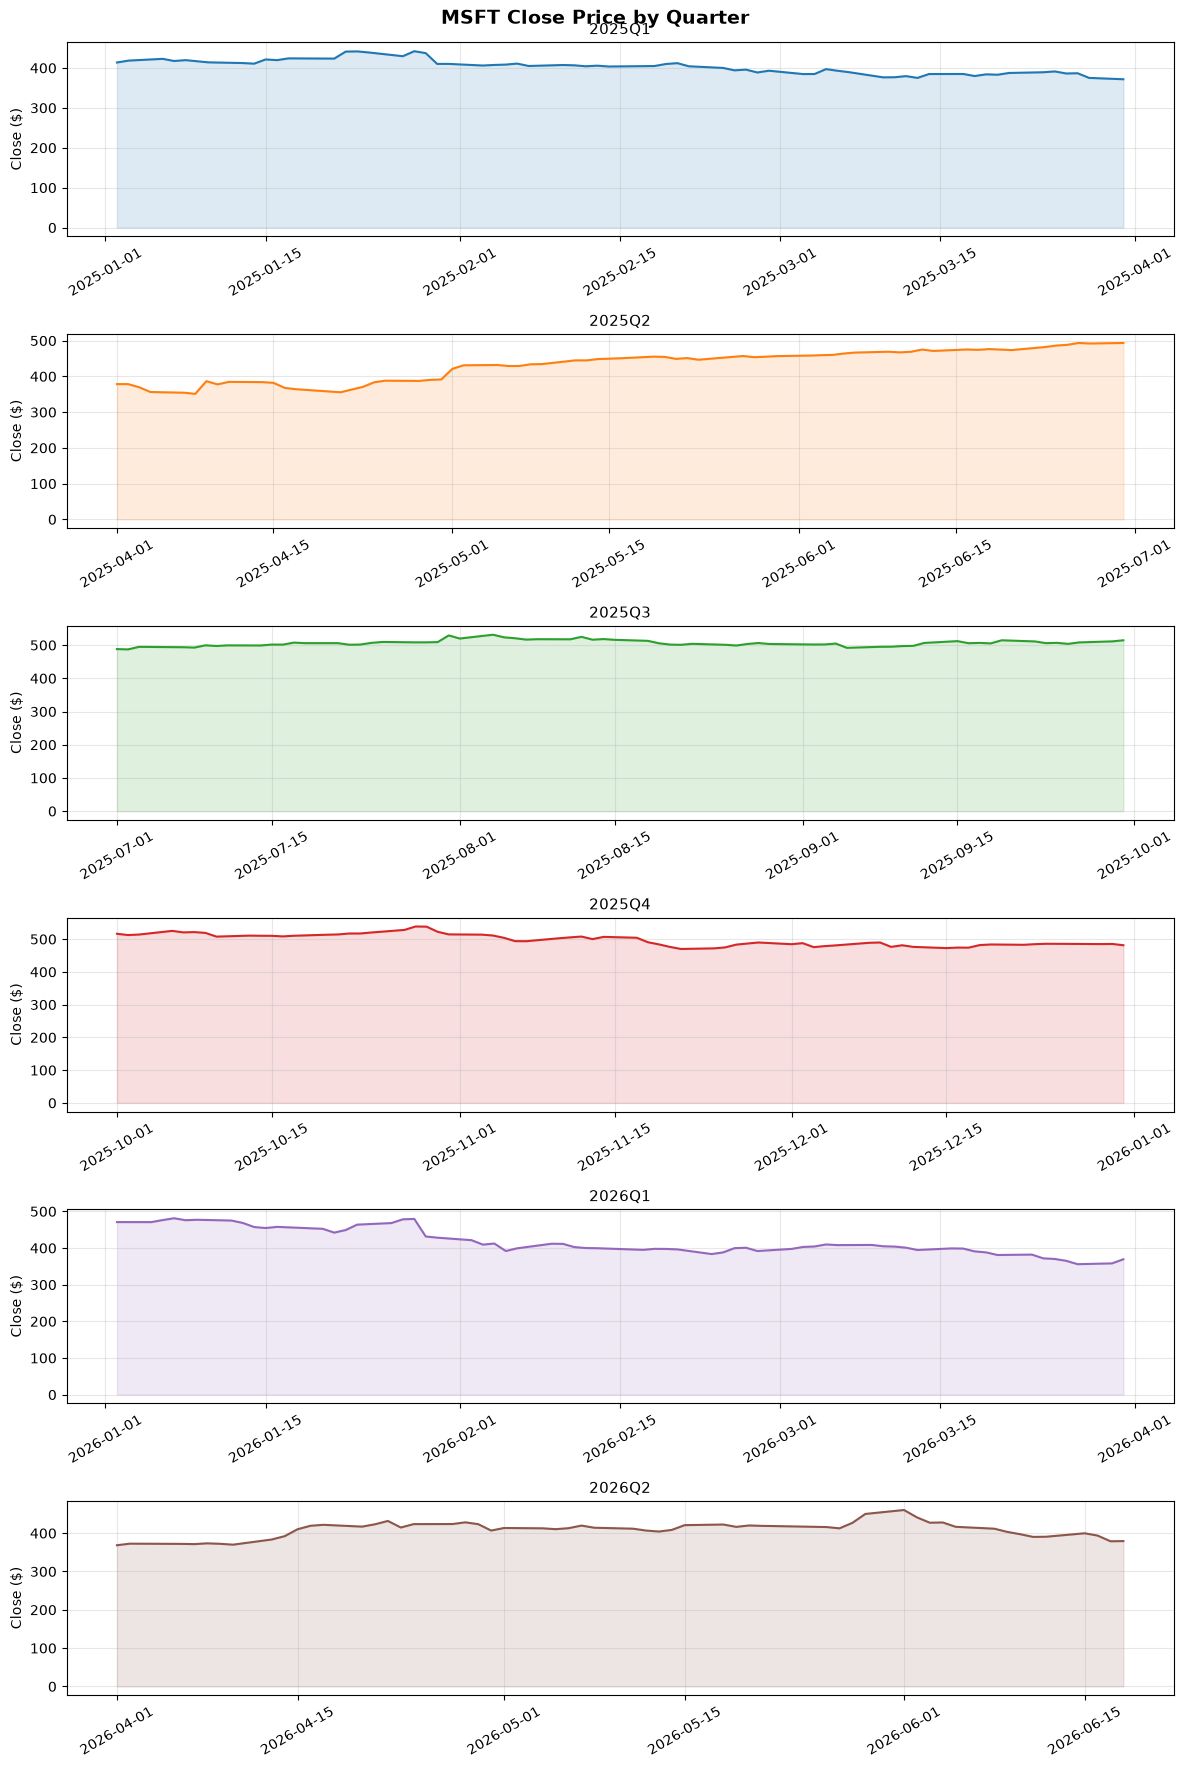

In [7]:
close = df['Close'][ticker].reset_index()
close.columns = ['Date', 'Close']
close['Quarter'] = pd.PeriodIndex(close['Date'], freq='Q')

quarters = close['Quarter'].unique()
n = len(quarters)

fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

colors = plt.cm.tab10.colors
for i, (ax, q) in enumerate(zip(axes, quarters)):
    subset = close[close['Quarter'] == q]
    color = colors[i % len(colors)]
    ax.plot(subset['Date'], subset['Close'], color=color, linewidth=1.5)
    ax.fill_between(subset['Date'], subset['Close'], alpha=0.15, color=color)
    ax.set_title(str(q), fontsize=11)
    ax.set_ylabel('Close ($)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'{ticker} Close Price by Quarter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'MSFT Close Price'}, xlabel='Date'>

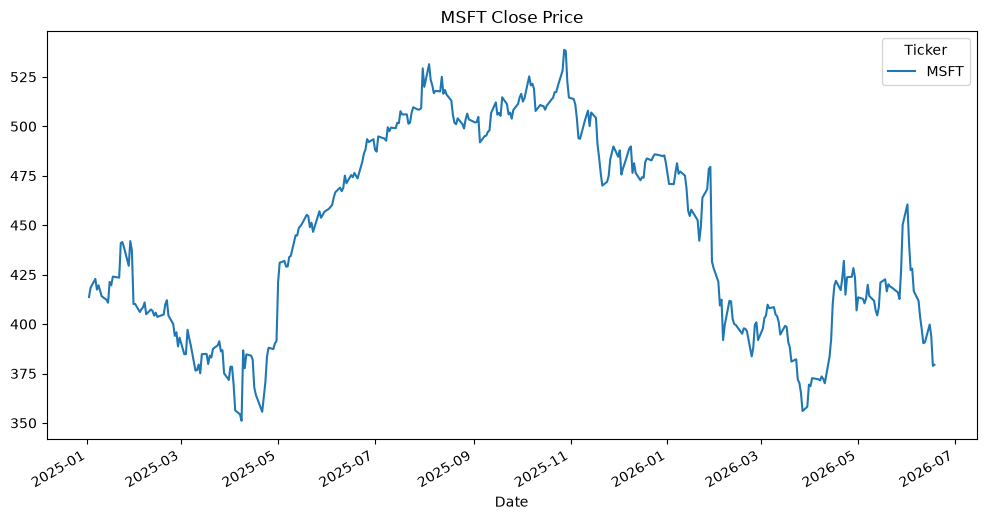

In [9]:
df.Close.plot(figsize=(12, 6), title=f'{ticker} Close Price', grid=False)

In [10]:
scaler = StandardScaler()

df.Close = scaler.fit_transform(df.Close)

df.Close

Ticker,MSFT
Date,
2025-01-02,-0.636381
2025-01-03,-0.542602
2025-01-06,-0.454130
2025-01-07,-0.561870
2025-01-08,-0.518813
...,...
2026-06-12,-1.092591
2026-06-15,-0.913151
2026-06-16,-1.031120


In [11]:
seq_length = 30 # number of days
data = []

for i in range(len(df.Close) - seq_length):
  data.append(df.Close[i:i+seq_length])

data = np.array(data)
data

array([[[-0.6363812 ],
        [-0.54260184],
        [-0.45413036],
        ...,
        [-0.82393991],
        [-0.79445002],
        [-0.83593256]],

       [[-0.54260184],
        [-0.45413036],
        [-0.56186998],
        ...,
        [-0.79445002],
        [-0.83593256],
        [-0.81214395]],

       [[-0.45413036],
        [-0.56186998],
        [-0.51881263],
        ...,
        [-0.83593256],
        [-0.81214395],
        [-0.71128763]],

       ...,

       [[-0.65521162],
        [-0.69967624],
        [-0.64846249],
        ...,
        [-1.10054805],
        [-1.09259079],
        [-0.91315144]],

       [[-0.69967624],
        [-0.64846249],
        [-0.51328073],
        ...,
        [-1.09259079],
        [-0.91315144],
        [-1.03112009]],

       [[-0.64846249],
        [-0.51328073],
        [-0.62543579],
        ...,
        [-0.91315144],
        [-1.03112009],
        [-1.3279301 ]]], shape=(336, 30, 1))

In [12]:
train_size = int(len(data) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1, :]).float().to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).float().to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).float().to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).float().to(device)

In [13]:
X_train

tensor([[[-0.6364],
         [-0.5426],
         [-0.4541],
         ...,
         [-0.7768],
         [-0.8239],
         [-0.7945]],

        [[-0.5426],
         [-0.4541],
         [-0.5619],
         ...,
         [-0.8239],
         [-0.7945],
         [-0.8359]],

        [[-0.4541],
         [-0.5619],
         [-0.5188],
         ...,
         [-0.7945],
         [-0.8359],
         [-0.8121]],

        ...,

        [[ 0.4483],
         [ 0.6523],
         [ 0.6730],
         ...,
         [-0.8224],
         [-0.7136],
         [-0.7477]],

        [[ 0.6523],
         [ 0.6730],
         [-0.2802],
         ...,
         [-0.7136],
         [-0.7477],
         [-0.7388]],

        [[ 0.6730],
         [-0.2802],
         [-0.3438],
         ...,
         [-0.7477],
         [-0.7388],
         [-0.8112]]], device='cuda:0')

In [14]:
y_train

tensor([[-0.8359],
        [-0.8121],
        [-0.7113],
        [-0.6681],
        [-0.8242],
        [-0.9071],
        [-1.0273],
        [-0.9912],
        [-1.1331],
        [-1.0452],
        [-1.2126],
        [-1.2103],
        [-0.9658],
        [-1.0472],
        [-1.1177],
        [-1.3767],
        [-1.3710],
        [-1.3155],
        [-1.4041],
        [-1.2113],
        [-1.2085],
        [-1.3106],
        [-1.2258],
        [-1.2451],
        [-1.1581],
        [-1.1222],
        [-1.0812],
        [-1.1835],
        [-1.1715],
        [-1.4035],
        [-1.4707],
        [-1.3368],
        [-1.3377],
        [-1.5156],
        [-1.7770],
        [-1.8160],
        [-1.8811],
        [-1.1732],
        [-1.3533],
        [-1.2134],
        [-1.2260],
        [-1.2670],
        [-1.5452],
        [-1.6206],
        [-1.7912],
        [-1.6395],
        [-1.4904],
        [-1.2361],
        [-1.1465],
        [-1.1600],
        [-1.1033],
        [-1.0793],
        [-0.

In [15]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

In [18]:
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
num_epochs = 200

for epoch in range(num_epochs):
    y_train_pred = model(X_train)
    loss = criterion(y_train_pred, y_train)

    if (epoch+1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch [20/200], Loss: 0.0553
Epoch [40/200], Loss: 0.0375
Epoch [60/200], Loss: 0.0307
Epoch [80/200], Loss: 0.0259
Epoch [100/200], Loss: 0.0224
Epoch [120/200], Loss: 0.0201
Epoch [140/200], Loss: 0.0191
Epoch [160/200], Loss: 0.0188
Epoch [180/200], Loss: 0.0187
Epoch [200/200], Loss: 0.0185


In [19]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.cpu().detach().numpy())
y_train = scaler.inverse_transform(y_train.cpu().detach().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.cpu().detach().numpy())
y_test = scaler.inverse_transform(y_test.cpu().detach().numpy())


In [20]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [ ]:
print(f'Train RMSE: {train_rmse:.2f}')
print(f'Test RMSE: {test_rmse:.2f}')

Train RMSE: 6.85
Test RMSE: 8.04


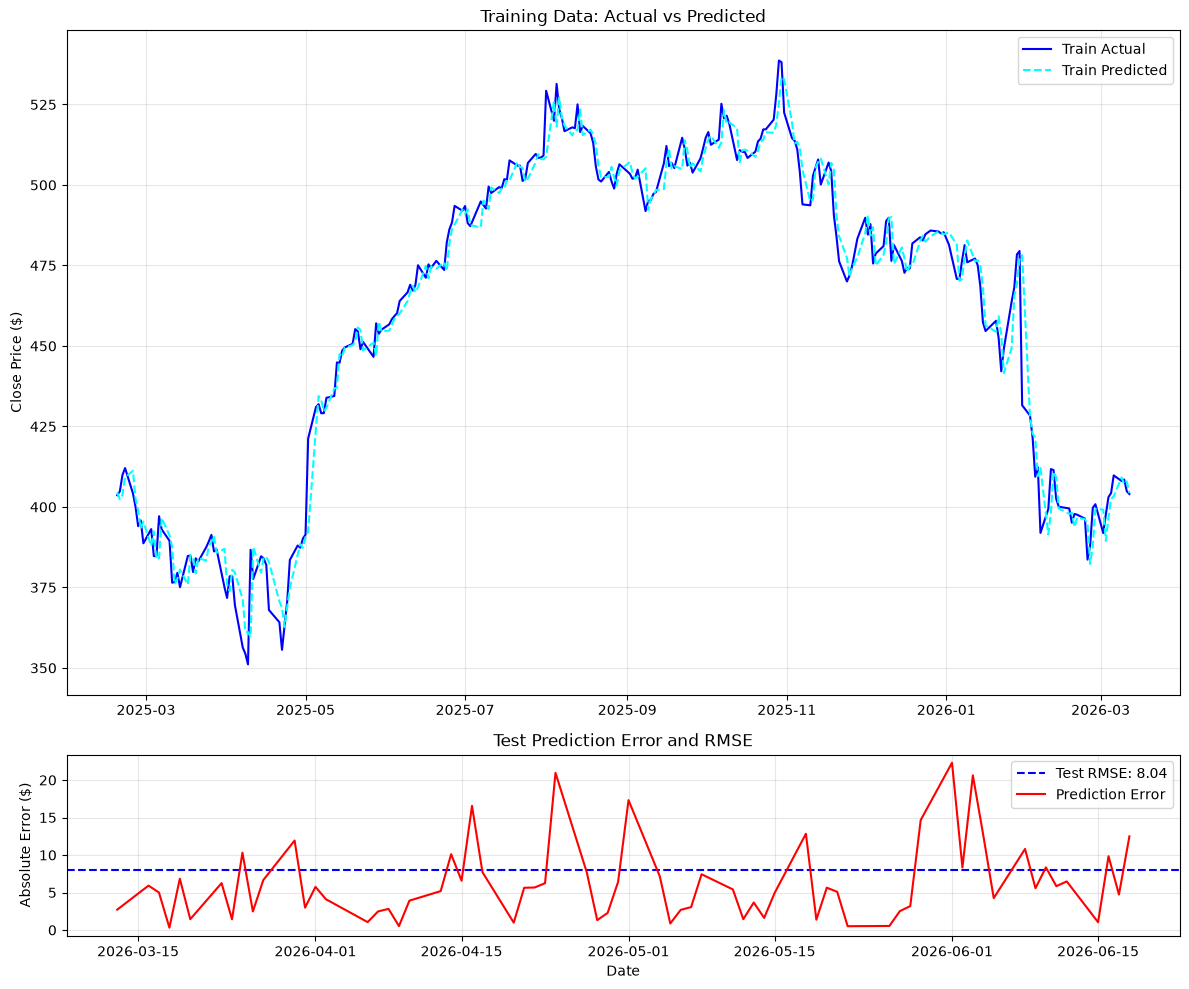

In [23]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.index[seq_length:train_size+seq_length], y_train[:, 0], label='Train Actual', color='blue')
ax1.plot(df.index[seq_length:train_size+seq_length], y_train_pred[:, 0], label='Train Predicted', color='cyan', linestyle='--')
ax1.set_title('Training Data: Actual vs Predicted', fontsize=12)
ax1.set_ylabel('Close Price ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# test actual vs test predicted with rmse in the middle
ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label=f'Test RMSE: {test_rmse:.2f}')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), label='Prediction Error', color='red')
ax2.legend()
plt.title('Test Prediction Error and RMSE', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Absolute Error ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# plot according to rmse